In [1]:
!pip install ta

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from ta.trend import MACD

df = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
log_returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

print(df.shape)
df.head()

(1509, 6)


,AAPL,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,
2018-01-02,40.304173,125.150002,85.901260,78.870331,4.928267,236.562149
2018-01-03,40.297161,124.820000,85.988800,79.237427,5.252615,238.058533
2018-01-04,40.484337,125.459999,87.220642,79.934799,5.280302,239.061829
2018-01-05,40.945259,125.330002,86.660713,80.925865,5.325049,240.654968
2018-01-08,40.793182,125.309998,86.788704,81.008453,5.488214,241.095078


In [3]:
ASSETS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'SPY', 'GLD']

# Load volume data
df_volume = pd.read_csv("../data/volume.csv", index_col=0, parse_dates=True)

def build_features(prices, returns, volume, asset):
    feat = pd.DataFrame(index=prices.index)
    feat['return'] = returns[asset].shift(1)
    feat['momentum_5'] = returns[asset].rolling(5).mean().shift(1)
    feat['momentum_10'] = returns[asset].rolling(10).mean().shift(1)
    feat['volatility_10'] = returns[asset].rolling(10).std().shift(1)
    feat['volatility_20'] = returns[asset].rolling(20).std().shift(1)
    feat['ma_10'] = prices[asset].rolling(10).mean().shift(1)
    feat['ma_50'] = prices[asset].rolling(50).mean().shift(1)
    feat['ma_ratio'] = feat['ma_10'] / feat['ma_50']
    feat['rsi'] = RSIIndicator(prices[asset], window=14).rsi().shift(1)
    macd = MACD(prices[asset])
    feat['macd'] = macd.macd().shift(1)
    feat['macd_signal'] = macd.macd_signal().shift(1)
    feat['volume'] = volume[asset].shift(1)
    feat['volume_ma_10'] = volume[asset].rolling(10).mean().shift(1)
    feat['volume_ratio'] = (volume[asset] / volume[asset].rolling(10).mean()).shift(1)
    feat['spy_return'] = returns['SPY'].shift(1)
    feat['spy_momentum'] = returns['SPY'].rolling(5).mean().shift(1)
    feat['corr_spy'] = returns[asset].rolling(20).corr(returns['SPY']).shift(1)
    feat['day_of_week'] = prices.index.dayofweek
    feat['target'] = returns[asset].shift(-1)
    return feat

# Rebuild all features
all_features = {}
for asset in ASSETS:
    feat = build_features(df, log_returns, df_volume, asset)
    feat = feat.dropna()
    all_features[asset] = feat
    print(f"{asset}: {feat.shape}")

import pickle
with open("../data/all_features.pkl", "wb") as f:
    pickle.dump(all_features, f)

print("\nFeatures saved!")

AAPL: (1458, 19)
MSFT: (1458, 19)
NVDA: (1458, 19)
JPM: (1458, 19)
SPY: (1458, 19)
GLD: (1458, 19)

Features saved!


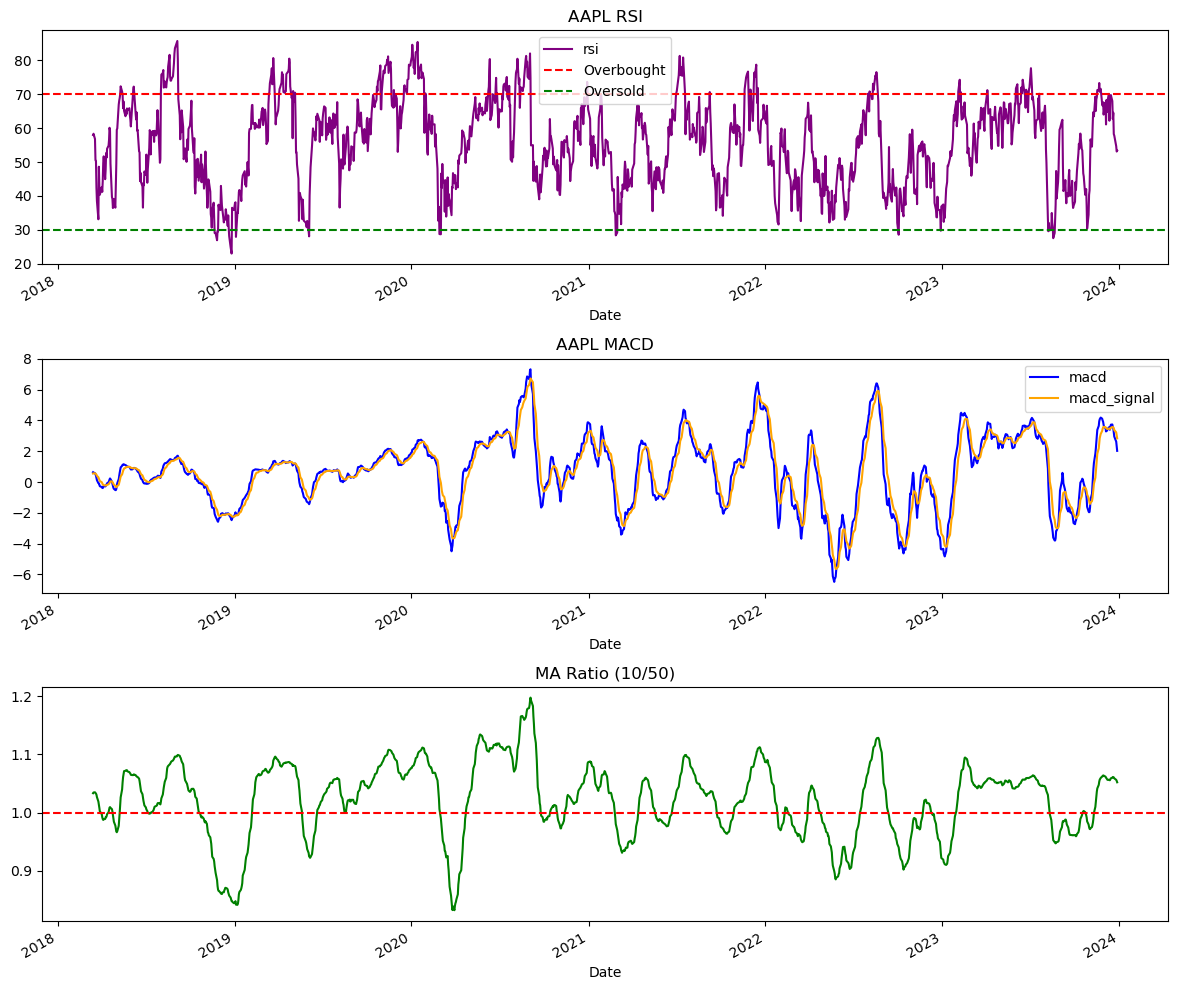

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sample = all_features['AAPL']

sample['rsi'].plot(ax=axes[0], title='AAPL RSI', color='purple')
axes[0].axhline(70, color='red', linestyle='--', label='Overbought')
axes[0].axhline(30, color='green', linestyle='--', label='Oversold')
axes[0].legend()

sample['macd'].plot(ax=axes[1], title='AAPL MACD', color='blue')
sample['macd_signal'].plot(ax=axes[1], color='orange')
axes[1].legend()

sample['ma_ratio'].plot(ax=axes[2], title='MA Ratio (10/50)', color='green')
axes[2].axhline(1, color='red', linestyle='--')

plt.tight_layout()
plt.show()